In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [2]:
glass = pd.read_csv('glass.data', header=None)

glass 

,0,1,2,3,4,5,6,7,8,9,10
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
209,210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,213,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [3]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import numpy as np
from sklearn.svm import SVC

df = glass
X = df.drop(columns=[10]).values
y_raw = df[10].values

major_class = Counter(y_raw).most_common(1)[0][0]
y = np.where(y_raw == major_class, 0, 1)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}
for C in [0.1, 1, 10, 100, 1000]:
    for gamma in [0.01, 0.1, 0.5, 0.8, 1, 1.5, 2]:
        fold_accuracies = []
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            clf = SVC(kernel='rbf', C=C, gamma=gamma)
            clf.fit(X_train, y_train)

            test_pred = clf.predict(X_test)
            acc = np.mean(test_pred == y_test)
            fold_accuracies.append(acc)
            print(f"C={C}, gamma={gamma}, Fold {fold}: Test Accuracy = {acc:.4f}")

        mean_acc = np.mean(fold_accuracies)
        std_acc  = np.std(fold_accuracies)

        results[(C, gamma)] = (mean_acc, std_acc)

        print(f"C={C}, gamma={gamma} → Mean = {mean_acc:.4f}, Std = {std_acc:.4f}\n")



C=0.1, gamma=0.01, Fold 1: Test Accuracy = 0.9091
C=0.1, gamma=0.01, Fold 2: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 3: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 4: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 5: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 6: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 7: Test Accuracy = 0.9524
C=0.1, gamma=0.01, Fold 8: Test Accuracy = 0.9048
C=0.1, gamma=0.01, Fold 9: Test Accuracy = 1.0000
C=0.1, gamma=0.01, Fold 10: Test Accuracy = 1.0000
C=0.1, gamma=0.01 → Mean = 0.9766, Std = 0.0376

C=0.1, gamma=0.1, Fold 1: Test Accuracy = 0.6364
C=0.1, gamma=0.1, Fold 2: Test Accuracy = 0.6364
C=0.1, gamma=0.1, Fold 3: Test Accuracy = 0.6364
C=0.1, gamma=0.1, Fold 4: Test Accuracy = 0.6364
C=0.1, gamma=0.1, Fold 5: Test Accuracy = 0.6667
C=0.1, gamma=0.1, Fold 6: Test Accuracy = 0.6667
C=0.1, gamma=0.1, Fold 7: Test Accuracy = 0.6667
C=0.1, gamma=0.1, Fold 8: Test Accuracy = 0.6667
C=0.1, gamma=0.1, Fold 9: Test Accuracy = 0.6190
C=0.1, ga

In [4]:
results

{(0.1, 0.01): (np.float64(0.9766233766233766), np.float64(0.0376000878798415)),
 (0.1, 0.1): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (0.1, 0.5): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (0.1, 0.8): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (0.1, 1): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (0.1, 1.5): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (0.1, 2): (np.float64(0.645021645021645), np.float64(0.018770115488033572)),
 (1, 0.01): (np.float64(0.9861471861471862), np.float64(0.021167901607614975)),
 (1, 0.1): (np.float64(0.985930735930736), np.float64(0.021498421291487296)),
 (1, 0.5): (np.float64(0.924891774891775), np.float64(0.03786394266921203)),
 (1, 0.8): (np.float64(0.887878787878788), np.float64(0.051155571417220595)),
 (1, 1): (np.float64(0.7993506493506494), np.float64(0.05432038012990101)),
 (1, 1.5): (np.float64(0.6545454545454547), np.float64(

In [5]:
df_results = pd.DataFrame(
    [(C, gamma, mean, std) for (C, gamma), (mean, std) in results.items()],
    columns=["C", "gamma", "mean", "std"]
)

table_mean = df_results.pivot(index="C", columns="gamma", values="mean")
table_std  = df_results.pivot(index="C", columns="gamma", values="std")

print("=== Média da Acurácia ===")
print(table_mean.round(3))
print("\n=== Desvio Padrão ===")
print(table_std.round(3))

=== Média da Acurácia ===
gamma    0.01   0.10   0.50   0.80   1.00   1.50   2.00
C                                                      
0.1     0.977  0.645  0.645  0.645  0.645  0.645  0.645
1.0     0.986  0.986  0.925  0.888  0.799  0.655  0.645
10.0    1.000  0.986  0.930  0.911  0.874  0.725  0.645
100.0   1.000  0.986  0.930  0.911  0.874  0.725  0.645
1000.0  1.000  0.986  0.930  0.911  0.874  0.725  0.645

=== Desvio Padrão ===
gamma    0.01   0.10   0.50   0.80   1.00   1.50   2.00
C                                                      
0.1     0.038  0.019  0.019  0.019  0.019  0.019  0.019
1.0     0.021  0.021  0.038  0.051  0.054  0.026  0.019
10.0    0.000  0.021  0.038  0.044  0.062  0.041  0.019
100.0   0.000  0.021  0.038  0.044  0.062  0.041  0.019
1000.0  0.000  0.021  0.038  0.044  0.062  0.041  0.019


In [9]:
df = glass
X = df.drop(columns=[10]).values
y_raw = df[10].values

major_class = Counter(y_raw).most_common(1)[0][0]
y = np.where(y_raw == major_class, -1, 1)

In [12]:
len(y)

214

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [14]:
gamma = 0.1
C = 10
clf = SVC(kernel='rbf', gamma=gamma, C=C)
clf.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [15]:
dual_coef = clf.dual_coef_[0] # coeficientes (com sinal)
support_idx = clf.support_
alphas = np.abs(dual_coef) # valores positivos de alpha
ys = np.sign(dual_coef) # sinal corresponde ao y_i
SVs = clf.support_vectors_
b = clf.intercept_[0]

In [17]:
def rbf_kernel_point(x, X_sv, gamma):
    return np.exp(-gamma * np.linalg.norm(X_sv - x, axis=1)**2)
def contributions(x):
    K = rbf_kernel_point(x, SVs, gamma)
    P = np.sum(alphas[ys > 0] * K[ys > 0]) # contribuição positiva
    N = np.sum(alphas[ys < 0] * K[ys < 0]) # contribuição negativa
    f_val = P - N + b
    return N, P, f_val

In [19]:
N_coords = []
P_coords = []
f_vals = []
for xi in X:
    N_val, P_val, f_val = contributions(xi)
    N_coords.append(N_val)
    P_coords.append(P_val)
    f_vals.append(f_val)
N_coords = np.array(N_coords)
P_coords = np.array(P_coords)
f_vals = np.array(f_vals)

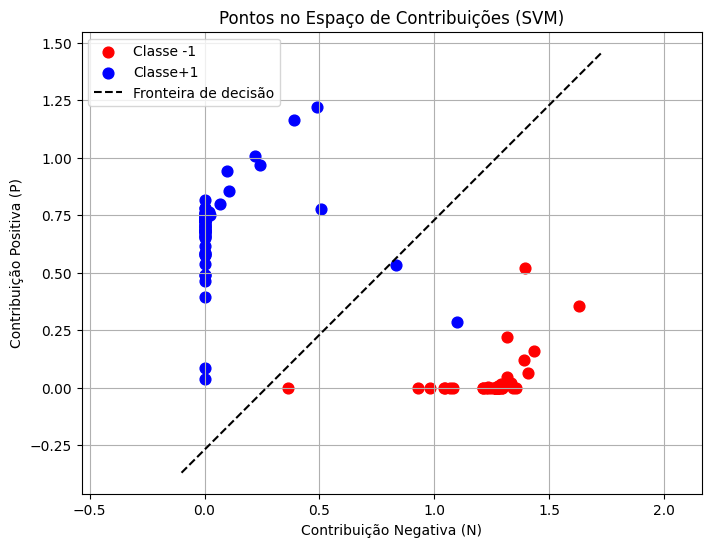

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(N_coords[y==-1], P_coords[y==-1], color='red', label='Classe -1', s=60)
plt.scatter(N_coords[y==+1], P_coords[y==+1], color='blue', label='Classe+1', s=60)
n_line = np.linspace(min(N_coords)-0.1, max(N_coords)+0.1, 100)
p_line = n_line - b
plt.plot(n_line, p_line, 'k--', label='Fronteira de decisão')
plt.xlabel('Contribuição Negativa (N)')
plt.ylabel('Contribuição Positiva (P)')
plt.title('Pontos no Espaço de Contribuições (SVM)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

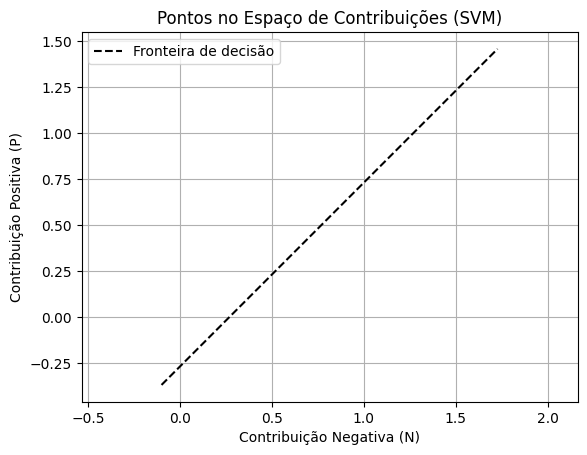

In [21]:
n_line = np.linspace(min(N_coords)-0.1, max(N_coords)+0.1, 100)
p_line = n_line - b
plt.plot(n_line, p_line, 'k--', label='Fronteira de decisão')
plt.xlabel('Contribuição Negativa (N)')
plt.ylabel('Contribuição Positiva (P)')
plt.title('Pontos no Espaço de Contribuições (SVM)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()